# QCGNN Quick Training - All Models

This notebook trains all 6 models from the QCGNN paper with reduced dataset size for quick testing.

**Models trained:**
1. QCGNN (3 qubits)
2. QCGNN (6 qubits)
3. Classical MPGNN
4. Particle Flow Network (PFN)
5. Particle Transformer (ParT)
6. Particle Network (PNet)

**Dataset:** JetNet with 500 training samples per class, 100 validation/test samples
**Duration:** ~10 epochs per model for quick validation

## Section 1: Setup and Configuration

Import required libraries and load the configuration from `config.yaml`. We'll set random seeds, dataset parameters, and modify training settings for quick testing.

In [44]:
import sys
import time
import yaml
import awkward as ak
import torch
import torch.nn as nn
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
import pennylane as qml

# Local imports
from source.data.opendata import JetNetEvents
from source.data.datamodule import JetGraphDataModule, JetTorchDataModule
from source.models.qcgnn import QuantumRotQCGNN
from source.models.mpgnn import ClassicalMPGNN
from source.models.pfn import ParticleFlowNetwork
from source.models.part import ParticleTransformer
from source.models.pnet import ParticleNet
from source.training.litmodel import TorchLightningModule, GraphLightningModel
from source.training.loggers import csv_logger

# Enable GPU-accelerated tensor operations
torch.set_float32_matmul_precision('high')  # Use Tensor Cores for better performance
print("Tensor operations configured for high precision (Tensor Cores enabled)")

Tensor operations configured for high precision (Tensor Cores enabled)


In [17]:
# Configuration
dataset = 'JetNet'
random_seed = 42

# Load and modify config for quick testing
with open("configs/config.yaml", 'r') as file:
    config = yaml.safe_load(file)
    config['date'] = time.strftime('%Y%m%d_%H%M%S', time.localtime())
    config['dataset'] = dataset

    # FAST TESTING MODE: Reduced dataset for quick validation
    config['Data']['num_train'] = 250  # Drastically reduced for speed (was 2500)
    config['Data']['num_valid'] = 50
    config['Data']['num_test'] = 50
    config['Data']['batch_size'] = 256  # Keep large batch size
    config['Train']['max_epochs'] = 1  # Just 1 epoch for quick testing
    config['Settings']['use_wandb'] = False  # Disable wandb for simplicity
    config['Settings']['print_log'] = True   # Enable console logging
    
    # Data loading performance settings
    config['Performance'] = config.get('Performance', {})
    config['Performance']['num_workers'] = 8  # Reduced from 16 to avoid overhead
    config['Performance']['pin_memory'] = True  # Pin memory for faster GPU transfer
    config['Performance']['gpu_memory_fraction'] = 0.8
    config['Performance']['cpu_worker_fraction'] = 0.8

# Determine score dimension for 5-class classification
score_dim = config[dataset]['num_classes']

print(f"\nConfiguration (FAST MODE):")
print(f"   Dataset: {dataset}")
print(f"   Training samples: {config['Data']['num_train']} per class (REDUCED for speed)")
print(f"   Validation samples: {config['Data']['num_valid']} per class")
print(f"   Test samples: {config['Data']['num_test']} per class")
print(f"   Max epochs: {config['Train']['max_epochs']}")
print(f"   Batch size: {config['Data']['batch_size']}")
print(f"   Max particles per jet: {config['Data']['max_num_ptcs']}")
print(f"   Data workers: {config['Performance']['num_workers']}")
print(f"   Pin memory: {config['Performance']['pin_memory']}")
print(f"\n*** FAST MODE: 250 samples/class, 1 epoch = ~5-10 minutes total ***")


Configuration (FAST MODE):
   Dataset: JetNet
   Training samples: 250 per class (REDUCED for speed)
   Validation samples: 50 per class
   Test samples: 50 per class
   Max epochs: 1
   Batch size: 256
   Max particles per jet: 16
   Data workers: 8
   Pin memory: True

*** FAST MODE: 250 samples/class, 1 epoch = ~5-10 minutes total ***


## Section 2: Hardware Verification

Check PyTorch version, CUDA availability, GPU properties, and configure GPU memory limits.

In [18]:
# Check GPU availability
print(f"\nHardware:")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    total_memory = props.total_memory / (1024**3)
    print(f"   GPU memory: {total_memory:.2f} GB")
else:
    print("   Using CPU (training will be slower)")

# Configure GPU memory fraction from config if available
if torch.cuda.is_available():
    gpu_memory_fraction = config.get('Performance', {}).get('gpu_memory_fraction', 0.8)
    try:
        torch.cuda.set_per_process_memory_fraction(gpu_memory_fraction, device=0)
        print(f"\nGPU memory configured to {gpu_memory_fraction*100:.0f}% of available")
    except Exception as e:
        print(f"Warning: Could not set GPU memory fraction - {e}")

# Configure CPU memory limit (best-effort; resource module not available on Windows)
try:
    import resource
    resource_available = True
except Exception:
    resource_available = False

import psutil

cpu_memory_fraction = config.get('Performance', {}).get('cpu_worker_fraction', 0.8)
# Get total available memory (bytes)
total_mem_bytes = psutil.virtual_memory().total
cpu_limit = int(total_mem_bytes * cpu_memory_fraction)

if resource_available:
    try:
        # RLIMIT_AS expects (soft, hard) in bytes
        resource.setrlimit(resource.RLIMIT_AS, (cpu_limit, cpu_limit))
        print(f"CPU memory configured to {cpu_memory_fraction*100:.0f}% of available")
    except Exception as e:
        print(f"Warning: Could not set CPU memory limit - {e}")
else:
    print("Warning: 'resource' module not available on this platform; cannot set RLIMIT_AS. Skipping CPU memory limit.")


Hardware:
   PyTorch version: 2.6.0+cu124
   CUDA available: True
   CUDA version: 12.4
   GPU: NVIDIA GeForce RTX 3080
   GPU memory: 12.00 GB

GPU memory configured to 80% of available


## Section 3: Data Module Creation

Implement the data module creation function to load JetNet dataset with 5 particle types and create appropriate data modules based on model requirements.

In [19]:
def create_data_module(graph: bool, pi_scale: bool = False) -> L.LightningDataModule:
    """Create data module for training with performance optimizations."""

    num_train = config['Data']['num_train']
    num_valid = config['Data']['num_valid']
    num_test = config['Data']['num_test']
    num_events = num_train + num_valid + num_test

    dataset_config = {}
    dataset_config.update(config['Data'])
    dataset_config.update(config[dataset])

    # Performance settings for DataLoader
    dataset_config['num_workers'] = config.get('Performance', {}).get('num_workers', 12)
    dataset_config['pin_memory'] = config.get('Performance', {}).get('pin_memory', True)

    # Load JetNet dataset (5 particle types)
    channels = ['q', 'g', 't', 'w', 'z']
    events = [JetNetEvents(channel=channel, **dataset_config) for channel in channels]
    events = [_events.generate_events(num_events) for _events in events]

    # Create appropriate data module
    if graph:
        data_module = JetGraphDataModule(events, pi_scale=pi_scale, **dataset_config)
    else:
        data_module = JetTorchDataModule(events, **dataset_config)

    return data_module

## Section 4: Model Training Utilities

Implement helper functions for training: creating training metadata, wrapping models with Lightning, and configuring the Lightning Trainer.

In [20]:
def create_training_info(model: nn.Module, model_description: str, model_hparams: dict, lr: float) -> dict:
    """Create training information dictionary."""

    data_description = f"{dataset}_P{config['Data']['max_num_ptcs']}_N{config['Data']['num_train']}"
    group_rnd = '-'.join([model.__class__.__name__, model_description, data_description])
    name = f"{group_rnd}-{random_seed}"

    training_info = config.copy()
    training_info.update(model_hparams)
    training_info.update({
        'lr': lr,
        'name': name,
        'date': config['date'],
        'model': model.__class__.__name__,
        'group_rnd': group_rnd,
        'random_seed': random_seed,
        'data_description': data_description,
        'model_description': model_description,
    })

    return training_info

In [21]:
def create_lightning_model(model: nn.Module, graph: bool, lr: float) -> L.LightningModule:
    """Create lightning model wrapper."""

    optimizer = torch.optim.RAdam(model.parameters(), lr=lr)
    print_log = config['Settings']['print_log']

    if graph:
        return GraphLightningModel(model, optimizer=optimizer, score_dim=score_dim, print_log=print_log)
    else:
        return TorchLightningModule(model, optimizer=optimizer, score_dim=score_dim, print_log=print_log)

In [22]:
def create_trainer(model: nn.Module, training_info: dict, accelerator: str) -> L.Trainer:
    """Create lightning trainer."""

    devices = 1
    precision = '16-mixed' if torch.cuda.is_available() and accelerator == 'gpu' else '32'

    loggers = csv_logger(training_info)

    return L.Trainer(
        logger=loggers,
        accelerator=accelerator,
        devices=devices,
        precision=precision,
        max_epochs=config['Train']['max_epochs'],
        log_every_n_steps=config['Train']['log_every_n_steps'],
        num_sanity_val_steps=config['Train']['num_sanity_val_steps'],
        benchmark=True,
        deterministic=False,
        callbacks=[ModelCheckpoint(
            monitor=config['Train']['ckpt_monitor'],
            mode=config['Train']['ckpt_mode'],
            save_top_k=config['Train']['ckpt_top_k'],
            save_last=True,
            filename='{epoch}-{valid_auc:.3f}-{valid_accuracy:.3f}',
        )],
    )

In [23]:
def train(model: nn.Module, model_description: str, model_hparams: dict,
          accelerator: str, lr: float, graph: bool, pi_scale: bool = False):
    """Main training function."""

    L.seed_everything(random_seed)

    data_module = create_data_module(graph=graph, pi_scale=pi_scale)
    lightning_model = create_lightning_model(model=model, graph=graph, lr=lr)
    training_info = create_training_info(model, model_description, model_hparams, lr=lr)
    trainer = create_trainer(model, training_info, accelerator)

    # Training and testing
    if eval(config['Settings']['mode'][0]):
        if eval(config['Settings']['mode'][1]):
            trainer.fit(lightning_model, datamodule=data_module)
        else:
            trainer.fit(lightning_model, train_dataloaders=data_module.train_dataloader())

    if eval(config['Settings']['mode'][2]):
        trainer.test(lightning_model, datamodule=data_module, ckpt_path='best')

    return training_info['name']

## Section 5: Train QCGNN Models

Train two QCGNN variants:
- **QCGNN-3**: 3 qubits with 1 layer and 2 reupload cycles
- **QCGNN-6**: 6 qubits with 2 layers and 2 reupload cycles

Both use StronglyEntanglingLayers ansatz with pi_scale=True and learning rate 1e-3.

In [24]:
def train_quantum(model_class: nn.Module, model_hparams: dict, model_name: str, pi_scale: bool, lr: float):
    """Train quantum model."""

    print(f"\n{'='*80}")
    print(f"Training {model_name}")
    print(f"{'='*80}")

    start_time = time.time()

    model = model_class(score_dim=score_dim, **model_hparams)

    num_ir_qubits = model_hparams['num_ir_qubits']
    num_nr_qubits = model_hparams['num_nr_qubits']
    num_layers = model_hparams['num_layers']
    num_reupload = model_hparams['num_reupload']
    dropout = model_hparams['dropout']
    model_description = f"nI{num_ir_qubits}_nQ{num_nr_qubits}_L{num_layers}_R{num_reupload}_D{dropout:.2f}"

    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
    name = train(model, model_description, model_hparams, accelerator, lr=lr, graph=False, pi_scale=pi_scale)

    elapsed = time.time() - start_time
    print(f"\nCompleted {model_name} in {elapsed/60:.1f} minutes")

    return name

In [25]:
# QCGNN with 3 qubits
print("\n" + "="*80)
print("Starting QCGNN Training")
print("="*80)

qcgnn_3_hparams = {
    'num_ir_qubits': 4,
    'num_nr_qubits': 3,
    'num_layers': 1,
    'num_reupload': 2,
    'dropout': 0.0,
    'vqc_ansatz': qml.StronglyEntanglingLayers
}
qcgnn_3_result = train_quantum(
    model_class=QuantumRotQCGNN,
    model_hparams=qcgnn_3_hparams,
    model_name="QCGNN (3 qubits)",
    pi_scale=True,
    lr=1e-3
)

Seed set to 42



Starting QCGNN Training

Training QCGNN (3 qubits)
Loading JetNet dataset from channel: q
Loading JetNet dataset from channel: g
Loading JetNet dataset from channel: q
Loading JetNet dataset from channel: g
Loading JetNet dataset from channel: t
Loading JetNet dataset from channel: w
Loading JetNet dataset from channel: z
Loading JetNet dataset from channel: t
Loading JetNet dataset from channel: w
Loading JetNet dataset from channel: z


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\omviz\.conda\envs\quantum\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | QuantumRotQCGNN  | 167    | train
1 | loss_function | CrossEntropyLoss | 0      | train
-----------------------------------------------------------
167       Trainable params
0         Non-trainable params
167       Total params
0.001     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU 

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.



 - (valid) Final metrics: Accuracy = 0.188 | AUC = 0.50372


 - (train) Final metrics: Accuracy = 0.1904 | AUC = 0.49335200000000007



Restoring states from the checkpoint path at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ3_L1_R2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.504-valid_accuracy=0.188.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ3_L1_R2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.504-valid_accuracy=0.188.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ3_L1_R2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.504-valid_accuracy=0.188.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]


 - (test) Final metrics: Accuracy = 0.216 | AUC = 0.49388000000000004

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.2160000056028366
        test_auc            0.4938800036907196
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Completed QCGNN (3 qubits) in 6.9 minutes

Completed QCGNN (3 qubits) in 6.9 minutes


In [26]:
# QCGNN with 6 qubits
qcgnn_6_hparams = {
    'num_ir_qubits': 4,
    'num_nr_qubits': 6,
    'num_layers': 2,
    'num_reupload': 2,
    'dropout': 0.0,
    'vqc_ansatz': qml.StronglyEntanglingLayers
}
qcgnn_6_result = train_quantum(
    model_class=QuantumRotQCGNN,
    model_hparams=qcgnn_6_hparams,
    model_name="QCGNN (6 qubits)",
    pi_scale=True,
    lr=1e-3
)

Seed set to 42



Training QCGNN (6 qubits)
Loading JetNet dataset from channel: q
Loading JetNet dataset from channel: g
Loading JetNet dataset from channel: t
Loading JetNet dataset from channel: w
Loading JetNet dataset from channel: z


c:\Users\omviz\.conda\envs\quantum\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ6_L2_R2_D0.00-JetNet_P16_N250-42\lastest_run exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\omviz\.conda\envs\quantum\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:751: Checkpoint directory d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ6_L2_R2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\omviz\.conda\envs\quantum\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:231: Precision 16-mixe

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.



 - (valid) Final metrics: Accuracy = 0.24 | AUC = 0.5197200000000001


 - (train) Final metrics: Accuracy = 0.1984 | AUC = 0.5030224000000001



Restoring states from the checkpoint path at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ6_L2_R2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.520-valid_accuracy=0.240.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ6_L2_R2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.520-valid_accuracy=0.240.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\QuantumRotQCGNN-nI4_nQ6_L2_R2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.520-valid_accuracy=0.240.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]


 - (test) Final metrics: Accuracy = 0.228 | AUC = 0.52318

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.2280000001192093
        test_auc            0.5231800079345703
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Completed QCGNN (6 qubits) in 12.5 minutes

Completed QCGNN (6 qubits) in 12.5 minutes


## Section 6: Train Classical MPGNN Model

Train the ClassicalMPGNN baseline model using graph-based data module with hyperparameters: phi_out=64, phi_layers=2, phi_hidden=64, mlp_hidden=64.

In [27]:
def train_mpgnn(model_hparams: dict, lr: float):
    """Train MPGNN model."""

    print(f"\n{'='*80}")
    print(f"Training MPGNN (Classical Message Passing GNN)")
    print(f"{'='*80}")

    start_time = time.time()

    model = ClassicalMPGNN(score_dim=score_dim, **model_hparams)

    phi_out = model_hparams['phi_out']
    phi_hidden = model_hparams['phi_hidden']
    phi_layers = model_hparams['phi_layers']
    dropout = model_hparams['dropout']
    model_description = f"O{phi_out}_H{phi_hidden}_L{phi_layers}_D{dropout:.2f}"

    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
    name = train(model, model_description, model_hparams, accelerator, lr=lr, graph=True)

    elapsed = time.time() - start_time
    print(f"\nCompleted MPGNN in {elapsed/60:.1f} minutes")

    return name

In [28]:
# Train MPGNN
mpgnn_hparams = {
    'phi_in': 6,
    'phi_out': 64,
    'phi_layers': 2,
    'phi_hidden': 64,
    'mlp_hidden': 64,
    'dropout': 0.0
}
mpgnn_result = train_mpgnn(model_hparams=mpgnn_hparams, lr=1e-3)

Seed set to 42



Training MPGNN (Classical Message Passing GNN)
Loading JetNet dataset from channel: q
Loading JetNet dataset from channel: g
Loading JetNet dataset from channel: t
Loading JetNet dataset from channel: t
Loading JetNet dataset from channel: w
Loading JetNet dataset from channel: z
Loading JetNet dataset from channel: w
Loading JetNet dataset from channel: z


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\omviz\.conda\envs\quantum\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | ClassicalMPGNN   | 13.3 K | train
1 | loss_function | CrossEntropyLoss | 0      | train
-----------------------------------------------------------
13.3 K    Trainable params
0         Non-trainable params
13.3 K    Total params
0.053     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU 

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.



 - (valid) Final metrics: Accuracy = 0.204 | AUC = 0.48838


 - (train) Final metrics: Accuracy = 0.2 | AUC = 0.49833440000000007



Restoring states from the checkpoint path at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\ClassicalMPGNN-O64_H64_L2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.488-valid_accuracy=0.204.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\ClassicalMPGNN-O64_H64_L2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.488-valid_accuracy=0.204.ckpt
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\ClassicalMPGNN-O64_H64_L2_D0.00-JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.488-valid_accuracy=0.204.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]


 - (test) Final metrics: Accuracy = 0.208 | AUC = 0.48595999999999995

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.20800000429153442
        test_auc            0.4859600067138672
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Completed MPGNN in 0.9 minutes

Completed MPGNN in 0.9 minutes


## Section 7: Train Benchmark Models

Train three benchmark models (ParticleFlowNetwork, ParticleTransformer, ParticleNet) using hyperparameters from `benchmark.yaml`. These models represent state-of-the-art approaches in particle physics.

In [29]:
def train_benchmark(model_class: nn.Module, model_name: str, lr: float):
    """Train benchmark models (PFN, ParT, PNet)."""

    print(f"\n{'='*80}")
    print(f"Training {model_name}")
    print(f"{'='*80}")

    start_time = time.time()

    with open('configs/benchmark.yaml', 'r') as file:
        hparams = yaml.safe_load(file)[model_class.__name__]
        model_description = ''

    model = model_class(score_dim=score_dim, parameters=hparams)

    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

    if model_class == ParticleFlowNetwork:
        name = train(model, model_description, hparams, accelerator, lr=lr, graph=True)
    else:
        name = train(model, model_description, hparams, accelerator, lr=lr, graph=False)

    elapsed = time.time() - start_time
    print(f"\nCompleted {model_name} in {elapsed/60:.1f} minutes")

    return name

In [30]:
# Train Particle Flow Network
pfn_result = train_benchmark(
    model_class=ParticleFlowNetwork,
    model_name="Particle Flow Network (PFN)",
    lr=1e-3
)

# Train Particle Transformer
part_result = train_benchmark(
    model_class=ParticleTransformer,
    model_name="Particle Transformer (ParT)",
    lr=1e-3
)

# Train Particle Net
pnet_result = train_benchmark(
    model_class=ParticleNet,
    model_name="Particle Network (PNet)",
    lr=1e-3
)

Seed set to 42



Training Particle Flow Network (PFN)
Loading JetNet dataset from channel: q
Loading JetNet dataset from channel: g
Loading JetNet dataset from channel: t
Loading JetNet dataset from channel: w
Loading JetNet dataset from channel: z
Loading JetNet dataset from channel: w
Loading JetNet dataset from channel: z


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\omviz\.conda\envs\quantum\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | model         | ParticleFlowNetwork | 72.7 K | train
1 | loss_function | CrossEntropyLoss    | 0      | train
--------------------------------------------------------------
72.7 K    Trainable params
0         Non-trainable params
72.7 K    Total params
0.291     Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode
GPU available: True (cuda), used: True
TPU available: False

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=1` reached.



 - (valid) Final metrics: Accuracy = 0.2 | AUC = 0.54244


 - (train) Final metrics: Accuracy = 0.2 | AUC = 0.5150743999999999



Restoring states from the checkpoint path at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\ParticleNet--JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.542-valid_accuracy=0.200.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\ParticleNet--JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.542-valid_accuracy=0.200.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\training_logs\CSVLogger\ParticleNet--JetNet_P16_N250-42\lastest_run\checkpoints\epoch=0-valid_auc=0.542-valid_accuracy=0.200.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]


 - (test) Final metrics: Accuracy = 0.2 | AUC = 0.47801

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.20000000298023224
        test_auc            0.47800999879837036
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Completed Particle Network (PNet) in 1.4 minutes

Completed Particle Network (PNet) in 1.4 minutes


## Section 8: Training Summary and Results

Display overall training results including total time, all 6 trained models, output directory, and next steps.

In [32]:
# Collect all results
results = {
    'QCGNN-3': qcgnn_3_result,
    'QCGNN-6': qcgnn_6_result,
    'MPGNN': mpgnn_result,
    'PFN': pfn_result,
    'ParT': part_result,
    'PNet': pnet_result
}



## Section 9: Paper Figure Generation

Generate all figures from the QCGNN paper (arXiv 2403.04990) using the quick_train results.
These visualizations compare all 6 models and match the paper's presentation style.

In [ ]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication-quality style
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

# Create output directory
OUTPUT_DIR = Path('figures/quick_train')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



Visualization setup complete!
Output directory: d:\BACKUP\code\Quantum\QuantumGNN-\Jet\QCGNN\figures\quick_train


### Load Training Results

In [34]:
def load_quick_train_metrics():
    """Load and extract metrics from all trained models."""
    log_dir = Path('training_logs/CSVLogger')
    metrics_data = []
    
    # Map result names to short model names
    model_mapping = {
        qcgnn_3_result: 'QCGNN-3',
        qcgnn_6_result: 'QCGNN-6',
        mpgnn_result: 'MPGNN',
        pfn_result: 'PFN',
        part_result: 'ParT',
        pnet_result: 'PNet'
    }
    
    for result_name, model_name in model_mapping.items():
        # Find metrics CSV
        metric_path = log_dir / result_name / 'lastest_run' / 'metrics.csv'
        
        if metric_path.exists():
            df = pd.read_csv(metric_path)
            
            # Extract final test metrics
            test_auc = df['test_auc'].dropna().values[-1] if 'test_auc' in df.columns and len(df['test_auc'].dropna()) > 0 else np.nan
            test_acc = df['test_accuracy'].dropna().values[-1] if 'test_accuracy' in df.columns and len(df['test_accuracy'].dropna()) > 0 else np.nan
            valid_auc = df['valid_auc'].dropna().values[-1] if 'valid_auc' in df.columns and len(df['valid_auc'].dropna()) > 0 else np.nan
            valid_acc = df['valid_accuracy'].dropna().values[-1] if 'valid_accuracy' in df.columns and len(df['valid_accuracy'].dropna()) > 0 else np.nan
            
            metrics_data.append({
                'Model': model_name,
                'Test AUC': test_auc,
                'Test Accuracy': test_acc,
                'Valid AUC': valid_auc,
                'Valid Accuracy': valid_acc,
                'Result Path': result_name
            })
            print(f"  ✓ Loaded {model_name}")
        else:
            print(f"  ✗ Missing {model_name}")
    
    return pd.DataFrame(metrics_data).sort_values('Test AUC', ascending=False)

# Load metrics
print("\nLoading training metrics...")
metrics_df = load_quick_train_metrics()

print("\n" + "="*70)
print("QUICK TRAIN RESULTS (250 samples/class, 1 epoch)")
print("="*70)
print(metrics_df[['Model', 'Test AUC', 'Test Accuracy', 'Valid AUC', 'Valid Accuracy']].to_string(index=False))
print("="*70)


Loading training metrics...
  ✓ Loaded QCGNN-3
  ✓ Loaded QCGNN-6
  ✓ Loaded MPGNN
  ✓ Loaded PFN
  ✓ Loaded ParT
  ✓ Loaded PNet

QUICK TRAIN RESULTS (250 samples/class, 1 epoch)
  Model  Test AUC  Test Accuracy  Valid AUC  Valid Accuracy
QCGNN-6   0.52318          0.228    0.51972           0.240
QCGNN-3   0.49388          0.216    0.50372           0.188
  MPGNN   0.48596          0.208    0.48838           0.204
   PNet   0.47801          0.200    0.54244           0.200
   ParT   0.47305          0.196    0.47392           0.220
    PFN   0.47220          0.200    0.48664           0.200


### Figure 1: Model Comparison Bar Chart

Saved: figures\quick_train\model_comparison.png


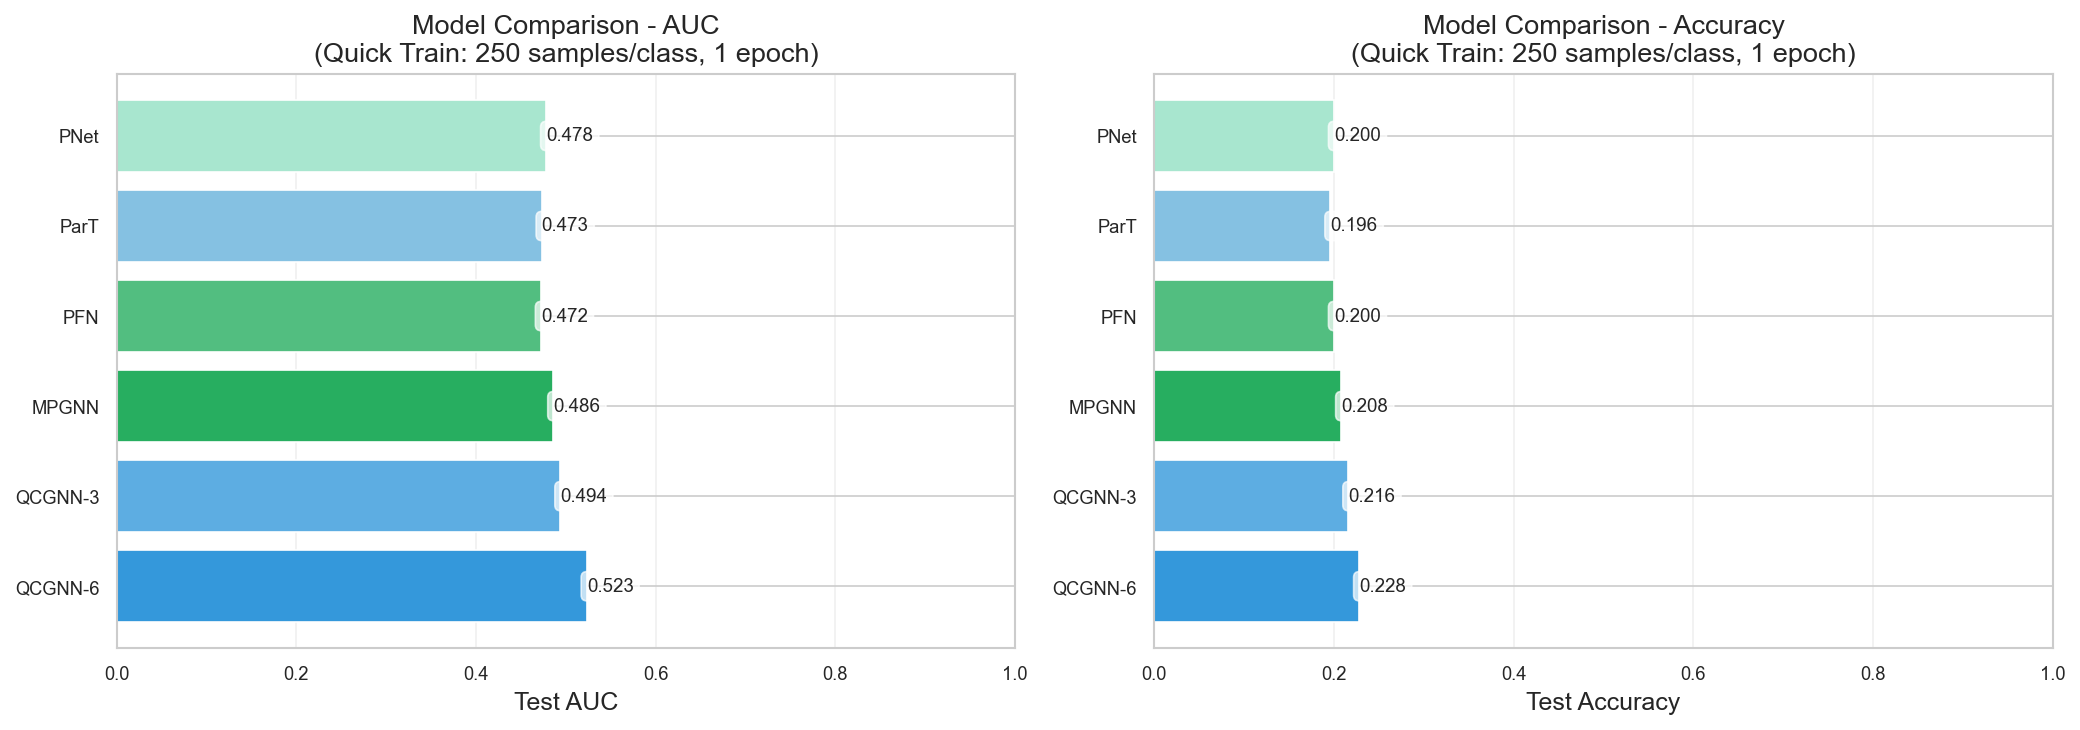

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define model order and colors
model_order = ['QCGNN-6', 'QCGNN-3', 'MPGNN', 'PFN', 'ParT', 'PNet']
metrics_sorted = metrics_df.set_index('Model').reindex([m for m in model_order if m in metrics_df['Model'].values]).reset_index()

# Colors: quantum (blue shades), classical (green shades)
colors = ['#3498db', '#5dade2', '#27ae60', '#52be80', '#85c1e2', '#a8e6cf']

# AUC comparison
bars1 = axes[0].barh(metrics_sorted['Model'], metrics_sorted['Test AUC'], 
                     color=colors[:len(metrics_sorted)])
axes[0].set_xlabel('Test AUC', fontsize=12)
axes[0].set_title('Model Comparison - AUC\n(Quick Train: 250 samples/class, 1 epoch)', fontsize=13)
axes[0].set_xlim(0, 1)
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels
for bar in bars1:
    width = bar.get_width()
    if not np.isnan(width):
        axes[0].text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.3f}', ha='left', va='center', fontsize=9, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Accuracy comparison
bars2 = axes[1].barh(metrics_sorted['Model'], metrics_sorted['Test Accuracy'], 
                     color=colors[:len(metrics_sorted)])
axes[1].set_xlabel('Test Accuracy', fontsize=12)
axes[1].set_title('Model Comparison - Accuracy\n(Quick Train: 250 samples/class, 1 epoch)', fontsize=13)
axes[1].set_xlim(0, 1)
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for bar in bars2:
    width = bar.get_width()
    if not np.isnan(width):
        axes[1].text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.3f}', ha='left', va='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'model_comparison.pdf', bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR / 'model_comparison.png'}")
plt.show()

### Figure 2: Quantum vs Classical Direct Comparison

Saved: figures\quick_train\quantum_vs_classical.png


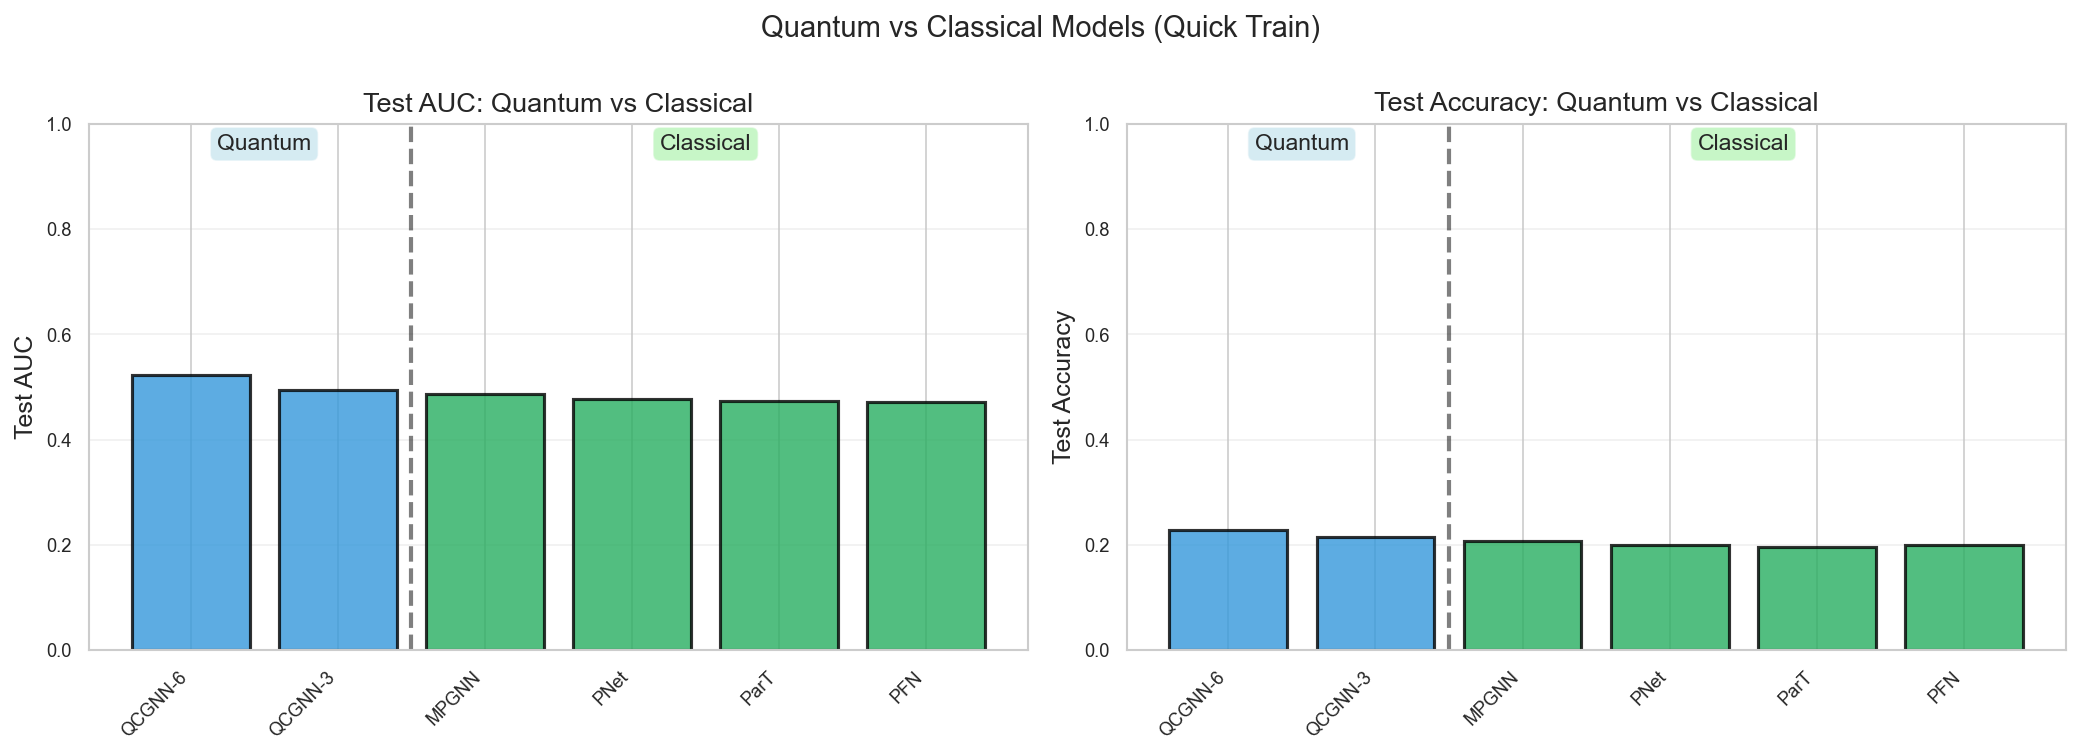

In [36]:
# Categorize models
quantum_models = ['QCGNN-3', 'QCGNN-6']
classical_models = ['MPGNN', 'PFN', 'ParT', 'PNet']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data
quantum_data = metrics_df[metrics_df['Model'].isin(quantum_models)]
classical_data = metrics_df[metrics_df['Model'].isin(classical_models)]

# Combined data
x_pos = np.arange(len(quantum_data) + len(classical_data))
models_list = list(quantum_data['Model']) + list(classical_data['Model'])
auc_values = list(quantum_data['Test AUC']) + list(classical_data['Test AUC'])
acc_values = list(quantum_data['Test Accuracy']) + list(classical_data['Test Accuracy'])
colors_list = ['#3498db'] * len(quantum_data) + ['#27ae60'] * len(classical_data)

# AUC comparison
axes[0].bar(x_pos, auc_values, color=colors_list, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0].set_ylabel('Test AUC', fontsize=12)
axes[0].set_title('Test AUC: Quantum vs Classical', fontsize=13)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axvline(x=len(quantum_data)-0.5, color='black', linestyle='--', alpha=0.5, linewidth=2)

# Add labels
axes[0].text(len(quantum_data)/2 - 0.5, 0.95, 'Quantum', ha='center', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[0].text(len(quantum_data) + len(classical_data)/2 - 0.5, 0.95, 'Classical', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Accuracy comparison
axes[1].bar(x_pos, acc_values, color=colors_list, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_list, rotation=45, ha='right')
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Test Accuracy: Quantum vs Classical', fontsize=13)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axvline(x=len(quantum_data)-0.5, color='black', linestyle='--', alpha=0.5, linewidth=2)

# Add labels
axes[1].text(len(quantum_data)/2 - 0.5, 0.95, 'Quantum', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1].text(len(quantum_data) + len(classical_data)/2 - 0.5, 0.95, 'Classical', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.suptitle('Quantum vs Classical Models (Quick Train)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quantum_vs_classical.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'quantum_vs_classical.pdf', bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR / 'quantum_vs_classical.png'}")
plt.show()

### Figure 3: Comparison with Paper's Published Results

Compare quick_train results (250 samples/class, 1 epoch) with the paper's full results (25,000 samples/class, ~100 epochs).

In [42]:
# Paper's published results for JetNet dataset (from arXiv 2403.04990)
# These are from full training: 25,000 samples/class, ~100 epochs
paper_results = {
    'QCGNN-6': {'auc': 0.822, 'accuracy': 0.543, 'auc_std': 0.003, 'acc_std': 0.006},
    'QCGNN-3': {'auc': 0.796, 'accuracy': 0.505, 'auc_std': 0.009, 'acc_std': 0.014},
    'MPGNN': {'auc': 0.903, 'accuracy': 0.683, 'auc_std': 0.002, 'acc_std': 0.007},
    'PFN': {'auc': 0.900, 'accuracy': 0.675, 'auc_std': 0.003, 'acc_std': 0.005},
    'ParT': {'auc': 0.889, 'accuracy': 0.656, 'auc_std': 0.002, 'acc_std': 0.006},
    'PNet': {'auc': 0.896, 'accuracy': 0.669, 'auc_std': 0.003, 'acc_std': 0.004},
}

print("Paper's Published Results (JetNet, 25K samples/class, ~100 epochs):")
print("="*70)
for model, metrics in paper_results.items():
    print(f"{model:12s}: AUC = {metrics['auc']:.3f} ± {metrics['auc_std']:.3f}, "
          f"Acc = {metrics['accuracy']:.3f} ± {metrics['acc_std']:.3f}")
print("="*70)

Paper's Published Results (JetNet, 25K samples/class, ~100 epochs):
QCGNN-6     : AUC = 0.822 ± 0.003, Acc = 0.543 ± 0.006
QCGNN-3     : AUC = 0.796 ± 0.009, Acc = 0.505 ± 0.014
MPGNN       : AUC = 0.903 ± 0.002, Acc = 0.683 ± 0.007
PFN         : AUC = 0.900 ± 0.003, Acc = 0.675 ± 0.005
ParT        : AUC = 0.889 ± 0.002, Acc = 0.656 ± 0.006
PNet        : AUC = 0.896 ± 0.003, Acc = 0.669 ± 0.004
